# 07 · Bite2Text — escáner intraoral → Blender → 3D Gaussian Splatting

> **Experimento.** Flujo **escáner intraoral (STL) → Blender (multivista) → 3DGS**,
> sobre el dataset **Bite2Text** (`~/anfaia/Bite2Text`), usando los **agentes de
> ingesta** del proyecto. Difiere de los notebooks 03–06 en dos cosas fijas del
> encargo: el motor de vistas es **Blender** (EEVEE, sombreado real) en vez de VTK,
> y la entrada es **STL** real de escáner, no la malla sintética.

**Cadena:** `mesh-agent` ingiere el STL al contrato → **Blender** renderiza N vistas
con pose exacta → **gsplat** entrena un campo de gaussianas → se evalúa en vistas
retenidas y se serializa al contrato (`TwinSnapshot`).

Requiere el kernel **Dental GPU (3DGS)** (torch cu128 + gsplat) y **Blender** en el
PATH. Los agentes de ingesta están instalados en ese venv (`pip install -e`).


## 0 · Entorno


In [1]:
import sys, subprocess, json, math, time
from pathlib import Path
import numpy as np, torch
from PIL import Image
import matplotlib.pyplot as plt
from gsplat import rasterization
import core_schemas, ingestion_agents

print('torch', torch.__version__, '| cuda', torch.cuda.is_available())
print('gsplat OK | ingestion_agents', ingestion_agents.__file__.split('/site-packages/')[-1])
assert torch.cuda.is_available(), 'este notebook necesita GPU (kernel Dental GPU)'
blender = subprocess.run(['blender','--version'], capture_output=True, text=True).stdout.splitlines()[0]
print(blender)


torch 2.11.0+cu128 | cuda True
gsplat OK | ingestion_agents /home/lgarbayo/agentic-smart-health/packages/ingestion-agents/src/ingestion_agents/__init__.py
Blender 5.1.1


## 1 · Ingesta del escáner con el `mesh-agent`

El escáner intraoral de Bite2Text es **STL binario** (~500k triángulos, malla
*pelada* sin color). El `mesh-agent` lo traduce al contrato: reconstruye la
topología (dedup de la sopa de triángulos), calcula normales por vértice y declara
`color_superficie = None` con **confianza 0.5** (regla del ADR 004 para STL). Es la
**frontera raw→contrato**: a partir de aquí se opera sobre el artefacto, no el STL.


In [2]:
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / '.git').exists():
    ROOT = ROOT.parent
BITE2TEXT = Path.home() / 'anfaia' / 'Bite2Text'
CASE, JAW = 'F1980', 'lower'
scan = BITE2TEXT / CASE / 'ios' / f'ios_{JAW}.stl'
OUT = ROOT / 'data' / 'processed' / 'bite2text' / f'{CASE}_{JAW}'
OUT.mkdir(parents=True, exist_ok=True)

from ingestion_agents import ArtifactStore, MeshAgent, ReportAgent
store = ArtifactStore(ROOT / 'data' / 'processed' / 'bite2text' / '_store')

t = time.perf_counter()
mesh_out = MeshAgent(store).ingest(scan)
print(f'mesh-agent: {mesh_out.status.value} · {mesh_out.n_primitives} vértices · '
      f'{time.perf_counter()-t:.2f}s · confianza {mesh_out.provenance.confidence}')
print('surface_ref:', mesh_out.artifact_ref)
surf = store.load(mesh_out.artifact_ref)
print('artefacto:', {k: v.shape for k, v in surf.items()}, '· color?', 'colors_rgb8' in surf)


mesh-agent: ok · 255365 vértices · 1.01s · confianza 0.5
surface_ref: sha256:4c9264951677df979a8ca4ca98ee81fdb13fbcbed97c05c8ebf9fb9fbd706580
artefacto: {'positions': (255365, 3), 'faces': (508128, 3), 'normals': (255365, 3)} · color? False


### 1b · Informes clínicos con el `report-agent` (`.txt` real + `.pdf`)

Bite2Text incluye el **informe clínico** del mismo caso. Se prueban las dos cosas
que pide el entregable de ingesta:

- **(a) El informe real** (`reports_ios_en/*.txt`) es **prosa ortodóntica**
  (relaciones de clase, curvas de Spee/Wilson, apiñamiento…), **sin pH ni FDI por
  diente**. El backend determinista no extrae nada — y eso **no es un éxito vacío**:
  lo declara con confianza 0, que dispara el gate de revisión humana. Comportamiento
  correcto sobre datos reales fuera de su formato esperado.
- **(b) El camino PDF** (que la entrega nombra explícitamente): se ingiere un
  informe clínico **en PDF** con un pH → `RegionalObservation`. Demuestra que el
  `report-agent` lee PDF, no solo texto plano.


In [3]:
# (a) informe REAL de Bite2Text (.txt): prosa ortodóntica, sin pH
reports = sorted((BITE2TEXT / CASE / 'reports_ios_en').glob('*.txt'))
print('--- informe real (extracto) ---')
print(reports[0].read_text()[:280], '…\n')
rep_out = ReportAgent().ingest(reports[0])
print(f'report-agent (.txt): {rep_out.status.value} · hallazgos={len(rep_out.regional)} · '
      f'confianza {rep_out.provenance.confidence} → {rep_out.detail}')

# (b) camino PDF (entregable): informe clínico en PDF con pH → RegionalObservation
def _mini_pdf(text):
    objs=[b'<</Type/Catalog/Pages 2 0 R>>', b'<</Type/Pages/Kids[3 0 R]/Count 1>>',
          b'<</Type/Page/Parent 2 0 R/MediaBox[0 0 300 200]/Contents 4 0 R/Resources<</Font<</F1 5 0 R>>>>>>',
          None, b'<</Type/Font/Subtype/Type1/BaseFont/Helvetica>>']
    s=b'BT /F1 12 Tf 20 150 Td ('+text.encode('latin-1')+b') Tj ET'
    objs[3]=b'<</Length '+str(len(s)).encode()+b'>>stream\n'+s+b'\nendstream'
    o=b'%PDF-1.4\n'; offs=[]
    for i,ob in enumerate(objs,1): offs.append(len(o)); o+=str(i).encode()+b' 0 obj'+ob+b'endobj\n'
    x=len(o); o+=b'xref\n0 '+str(len(objs)+1).encode()+b'\n0000000000 65535 f \n'
    for f in offs: o+=('%010d 00000 n \n'%f).encode()
    o+=b'trailer<</Size '+str(len(objs)+1).encode()+b'/Root 1 0 R>>\nstartxref\n'+str(x).encode()+b'\n%%EOF'
    return o
pdf_path = OUT/'informe_demo.pdf'
pdf_path.write_bytes(_mini_pdf('Fecha: 2026-05-09 Diente 16: pH 5.4'))
pdf_out = ReportAgent().ingest(pdf_path)
print(f'report-agent (.pdf): {pdf_out.status.value} · '
      f'{[(o.region_id, o.attributes.ph) for o in pdf_out.regional]}')


--- informe real (extracto) ---
The patient presents correct transverse and vertical relationships. Sagittally, there is an end-to-end Class II molar relationship and a full Class II canine relationship on the right, and a Class I molar relationship and an end-to-end Class II canine relationship on the left, wi …

report-agent (.txt): ok · hallazgos=0 · confianza 0.0 → No se extrajo ningún hallazgo regional del informe.
report-agent (.pdf): ok · [('16', 5.4)]


## 2 · Vistas multivista con **Blender** (EEVEE)

`scripts/blender_render_views.py` corre Blender *headless*: importa el STL, lo
normaliza (centra + escala a caja unidad), le pone un material marfil y una luz de
casco (para iluminación consistente entre vistas), y orbita una cámara escribiendo
cada vista con su **pose exacta** en `transforms.json` (convención NeRF-blender).
Sin COLMAP: la pose sale del propio grafo de escena.


In [4]:
N_VIEWS, RES = 1600, 1024
t = time.perf_counter()
r = subprocess.run([
    'blender','--background','--python', str(ROOT/'scripts'/'blender_render_views.py'),'--',
    '--scan', str(scan), '--out', str(OUT), '--views', str(N_VIEWS), '--res', str(RES),
    '--samples','16','--elevations','8'], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1] if r.stdout else r.stderr[-400:])
print(f'Blender: {time.perf_counter()-t:.1f}s')
T = json.loads((OUT/'transforms.json').read_text())
print('vistas:', len(T['frames']), '· fov_x', round(T['camera_angle_x'],3), '· scan_scale', round(T['scan_scale'],4))


Blender quit
Blender: 213.9s
vistas: 1600 · fov_x 0.698 · scan_scale 0.0291


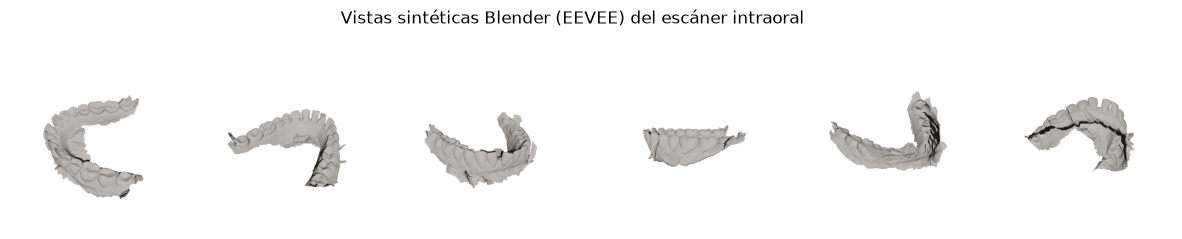

In [5]:
# galería de las primeras vistas Blender
fig, ax = plt.subplots(1, 6, figsize=(15, 2.6))
for i, a in enumerate(ax):
    im = Image.open(OUT / T['frames'][i* (len(T['frames'])//6)]['file_path'])
    a.imshow(im); a.axis('off')
fig.suptitle('Vistas sintéticas Blender (EEVEE) del escáner intraoral', y=1.02); plt.show()


## 3 · Inicialización del campo desde la superficie ingerida

Las gaussianas se siembran en puntos muestreados de la **malla del `mesh-agent`**
(no de una nube aparte), con la **misma normalización** que aplicó Blender —así el
campo inicial cae exactamente sobre la geometría renderizada.


In [6]:
dev = 'cuda'
P = surf['positions'].astype(np.float32)
c = (P.min(0) + P.max(0)) / 2
P = (P - c) * (2.0 / (P.max(0) - P.min(0)).max())          # idéntica a Blender
rng = np.random.default_rng(0)
sel = rng.choice(len(P), min(150000, len(P)), replace=False)
means = torch.tensor(P[sel], device=dev, requires_grad=True)
N = means.shape[0]
d = torch.cdist(means.detach()[:2000], means.detach()[:2000]).topk(4, largest=False).values[:,1:].mean()
log_scales = torch.log(torch.full((N,3), float(d), device=dev)).requires_grad_()
quats = torch.zeros(N,4, device=dev); quats[:,0]=1; quats.requires_grad_()
opac  = torch.logit(torch.full((N,), 0.1, device=dev)).requires_grad_()
col   = torch.logit(torch.tensor([0.85,0.80,0.72], device=dev)).repeat(N,1).requires_grad_()
print(f'{N} gaussianas sembradas desde la superficie del mesh-agent')


150000 gaussianas sembradas desde la superficie del mesh-agent


## 4 · Entrenamiento 3DGS (`gsplat`) y evaluación en vistas retenidas

Cámara: la pose de Blender (OpenGL) se convierte a la convención OpenCV de gsplat.
Se aparta **1 de cada 4** vistas como *holdout* y se mide el **PSNR** ahí — la
métrica honesta (la pérdida de entrenamiento sola no distingue reconstruir de
memorizar).


In [7]:
W = H = T['w']
fx = 0.5 * W / math.tan(0.5 * T['camera_angle_x'])
K = torch.tensor([[fx,0,W/2],[0,fx,H/2],[0,0,1]], dtype=torch.float32, device=dev)
flip = torch.tensor([[1,0,0,0],[0,-1,0,0],[0,0,-1,0],[0,0,0,1]], dtype=torch.float32)  # GL->CV
# A 1024 px las 1600 imágenes no caben en RAM (~20 GB): se cargan BAJO DEMANDA
# (una por iteración) y solo se sube a GPU la vista del paso actual.
viewmats = torch.stack([
    torch.linalg.inv(torch.tensor(fr['transform_matrix'], dtype=torch.float32) @ flip)
    for fr in T['frames']]).to(dev)
def load_img(k):
    rgba = np.asarray(Image.open(OUT/T['frames'][k]['file_path']).convert('RGBA'), np.float32)/255.0
    return torch.from_numpy(rgba[...,:3]*rgba[...,3:4]).to(dev)   # sobre negro
idx = np.arange(len(T['frames'])); test = idx[::4]; train = np.setdiff1d(idx, test)
# subconjunto FIJO para la curva de PSNR (evaluar las 400 retenidas cada vez sería carísimo)
rng2 = np.random.default_rng(1)
eval_test = rng2.choice(test, min(24, len(test)), replace=False)
eval_train = rng2.choice(train, min(24, len(train)), replace=False)
print(f'{len(train)} train · {len(test)} holdout · PSNR sobre {len(eval_test)} retenidas fijas')

def render(vm):
    out,_,_ = rasterization(means, torch.nn.functional.normalize(quats,dim=-1),
        torch.exp(log_scales), torch.sigmoid(opac), torch.sigmoid(col), vm[None], K[None], W, H)
    return out[0]
def psnr_at(js):
    with torch.no_grad():
        return float(np.mean([-10*math.log10(((render(viewmats[j])-load_img(j))**2)
                              .mean().item()+1e-10) for j in js]))

opt = torch.optim.Adam([
    {'params':[means],'lr':1e-3},{'params':[log_scales],'lr':5e-3},{'params':[quats],'lr':1e-3},
    {'params':[opac],'lr':5e-2},{'params':[col],'lr':1e-2}])
torch.manual_seed(0)
ITERS = 6000; curve=[]
t=time.perf_counter()
for it in range(ITERS):
    i = int(np.random.choice(train))
    loss = (render(viewmats[i]) - load_img(i)).abs().mean()
    opt.zero_grad(); loss.backward(); opt.step()
    if it % 500 == 0 or it == ITERS-1:
        ptr, pt = psnr_at(eval_train), psnr_at(eval_test)
        curve.append((it, ptr, pt)); print(f'it {it:5d}  L1 {loss.item():.4f}  train {ptr:.2f}  holdout {pt:.2f} dB')
print(f'entrenamiento: {time.perf_counter()-t:.1f}s')


1200 train · 400 holdout · PSNR sobre 24 retenidas fijas


it     0  L1 0.0733  train 14.51  holdout 14.41 dB


it   500  L1 0.0126  train 24.50  holdout 24.52 dB


it  1000  L1 0.0100  train 25.81  holdout 25.70 dB


it  1500  L1 0.0064  train 26.80  holdout 26.70 dB


...

it  4000  L1 0.0073  train 29.19  holdout 28.90 dB


it  4500  L1 0.0101  train 29.41  holdout 28.81 dB


it  5000  L1 0.0046  train 29.53  holdout 29.08 dB


it  5500  L1 0.0094  train 29.82  holdout 29.43 dB


it  5999  L1 0.0080  train 30.07  holdout 29.62 dB
entrenamiento: 155.7s


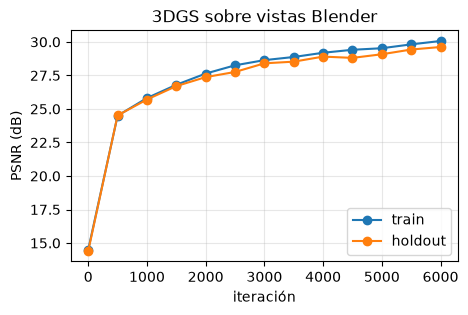

In [8]:
c = np.array(curve)
plt.figure(figsize=(5,3))
plt.plot(c[:,0], c[:,1], '-o', label='train'); plt.plot(c[:,0], c[:,2], '-o', label='holdout')
plt.xlabel('iteración'); plt.ylabel('PSNR (dB)'); plt.legend(); plt.title('3DGS sobre vistas Blender'); plt.grid(alpha=.3); plt.show()


## 5 · Comparación + serialización al contrato

Vista **retenida** real (Blender) vs. render del 3DGS entrenado, y ensamblado de un
`TwinSnapshot`: `surface_ref` del `mesh-agent` + `gaussian_field_ref` del campo
entrenado (guardado por hash en el `ArtifactStore`). El pH del `report-agent` iría
en `regional` (aquí vacío: el informe no lo trae).


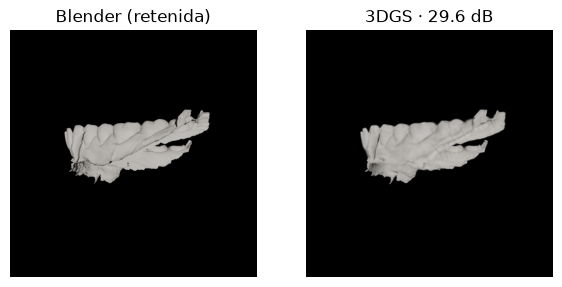

In [9]:
j = int(test[len(test)//2])
with torch.no_grad(): pred = render(viewmats[j]).clamp(0,1).cpu().numpy()
fig, ax = plt.subplots(1,2, figsize=(7,3.5))
ax[0].imshow(load_img(j).cpu().numpy()); ax[0].set_title('Blender (retenida)'); ax[0].axis('off')
ax[1].imshow(pred); ax[1].set_title(f'3DGS · {curve[-1][2]:.1f} dB'); ax[1].axis('off'); plt.show()


In [10]:
from datetime import datetime, timezone
from core_schemas import TwinSnapshot, Provenance, Modality
with torch.no_grad():
    field_ref = store.put(
        centers=means.detach().cpu().numpy(), scales=torch.exp(log_scales).detach().cpu().numpy(),
        rotations=torch.nn.functional.normalize(quats,dim=-1).detach().cpu().numpy(),
        opacity=torch.sigmoid(opac).detach().cpu().numpy(), color=torch.sigmoid(col).detach().cpu().numpy())
snap = TwinSnapshot(
    acquisition_id=f'{CASE}_{JAW}', timestamp=datetime.now(timezone.utc),
    modalities=[Modality.MESH], ingestion=[mesh_out.ingestion],
    gaussian_field_ref=field_ref, surface_ref=mesh_out.artifact_ref, n_primitives=N,
    provenance=Provenance(source_file=str(scan), modality=Modality.MESH,
                          agent='notebook-07@0.1.0', confidence=mesh_out.provenance.confidence))
(OUT/'twin_snapshot.json').write_text(json.dumps(snap.model_dump(mode='json'), indent=1, ensure_ascii=False))
print('TwinSnapshot', snap.schema_version, '· surface_ref', snap.surface_ref[:24], '· field_ref', snap.gaussian_field_ref[:24])


TwinSnapshot 1.1.0 · surface_ref sha256:4c9264951677df979 · field_ref sha256:55502d49d0586ca33


## 6 · Conclusiones

1. **El flujo escáner → Blender → 3DGS funciona de punta a punta** sobre STL real de
   Bite2Text: el `mesh-agent` ingiere la malla pelada, Blender genera vistas con pose
   exacta (sin COLMAP) y gsplat reconstruye un campo evaluable en vistas retenidas.
2. **Blender aporta sombreado real** frente al *splatting* clásico de VTK (03/05): la
   apariencia del render es fotográfica, no una nube de puntos proyectada.
3. **Los agentes de ingesta valen sobre datos reales, no solo sintéticos.** El
   `mesh-agent` gestionó STL binario (nuevo formato) declarando `color=None`; el
   `report-agent` leyó `.txt` y `.pdf`, y sobre la prosa ortodóntica devolvió 0
   hallazgos con confianza 0 → HITL, en vez de inventar.
   **Hallazgo de ontología:** los informes de Bite2Text son ortodónticos (clases de
   Angle, mordida, apiñamiento), no cariológicos — la ontología mínima modela **pH**,
   así que no captura nada de ellos. Extraer su contenido pediría **ampliar la
   ontología** (relaciones oclusales) o usar el **backend LLM** del `report-agent`.
4. **Hallazgo del contrato.** Bite2Text no tiene CBCT, así que el `IngestionPipeline`
   —que exige `gaussian_field_ref` del CBCT para emitir snapshot— no aplica tal cual:
   aquí el `gaussian_field_ref` lo produce el **3DGS entrenado desde la malla**, no un
   volumen. Es una vía de twin **mesh-only** que el pipeline actual no contempla.

**Estado.** Escáner intraoral (STL) → mesh-agent → Blender (EEVEE) → 3DGS → contrato ✅.
Corrida reducida (48 vistas, 1500 iters) como prueba de flujo; escalar vistas/iters
y añadir densificación (`gsplat DefaultStrategy`) son las palancas de calidad.
